
# Using VGG16 model, Adam optimisation tool, Learning rate = 0.001, batch size = 32, epoch = 100, then 100 (divided into 2 phases)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No single subdirectory or 'Data' subdirectory detected. Using EXTRACT_PATH as DATASET_PATH: /content/lung_cancer_data
Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Starting Phase 1: Training custom classification head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6487 - loss: 0.8468
Epoch 1: val_accuracy improved from -inf to 0.58904, saving model to best_lung_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 768ms/step - accuracy: 0.6524 - loss: 0.8390 - val_accuracy: 0.5890 - val_loss: 0.8484 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8779 - loss: 0.3351
Epoch 2: val_accuracy did not improve from 0.58904
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 637ms/step - accuracy: 0.8775 - loss: 0.3356 - val_accuracy: 0.5799 - val_loss: 0.8653 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9018 - loss: 0.2460
Epoch 3: val_accuracy did not improve from 0.58904
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 607ms/step - accuracy: 0.9014 - loss: 0.2470 - val_accuracy: 0.5799 - val_loss: 0.9021 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8964 - loss: 0.2633
Epoch 4: val_accuracy improved fr

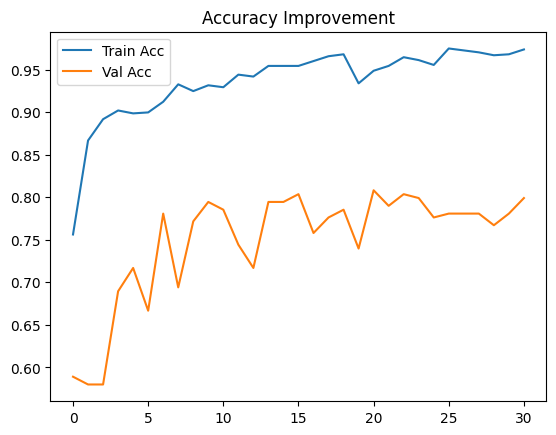

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 524ms/step - accuracy: 0.6970 - loss: 0.8507
Model Evaluation - Loss: 0.5929, Accuracy: 0.7808
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 492ms/step
Confusion Matrix


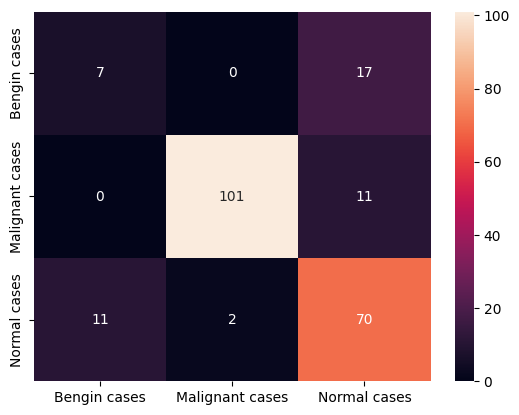

Classification Report
                 precision    recall  f1-score   support

   Bengin cases       0.39      0.29      0.33        24
Malignant cases       0.98      0.90      0.94       112
   Normal cases       0.71      0.84      0.77        83

       accuracy                           0.81       219
      macro avg       0.69      0.68      0.68       219
   weighted avg       0.81      0.81      0.81       219



In [2]:
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Extract Dataset
# Path where your zip file is located in Drive
ZIP_PATH = '/content/dataset.zip'
# Local folder in Colab (faster for training than reading directly from Drive)
EXTRACT_PATH = '/content/lung_cancer_data'

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"Extraction complete to {EXTRACT_PATH}")

# 3. Path Configuration
# After extraction, verify if there is a subfolder inside.
# If 'benign', 'malignant', 'normal' are inside a folder named 'Data',
# update this to: DATASET_PATH = os.path.join(EXTRACT_PATH, 'Data')

# Dynamically find the actual data directory if it's nested
DATASET_PATH = EXTRACT_PATH
subdirs = [d for d in os.listdir(EXTRACT_PATH) if os.path.isdir(os.path.join(EXTRACT_PATH, d))]

# Check if there's a single subdirectory that might contain the actual dataset
if len(subdirs) == 1:
    DATASET_PATH = os.path.join(EXTRACT_PATH, subdirs[0])
    print(f"Detected a single subdirectory '{subdirs[0]}'. Setting DATASET_PATH to: {DATASET_PATH}")
elif len(subdirs) > 1 and 'Data' in subdirs: # Specific check if 'Data' exists among multiple
    DATASET_PATH = os.path.join(EXTRACT_PATH, 'Data')
    print(f"Detected 'Data' subdirectory. Setting DATASET_PATH to: {DATASET_PATH}")
else:
    print(f"No single subdirectory or 'Data' subdirectory detected. Using EXTRACT_PATH as DATASET_PATH: {DATASET_PATH}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Define the actual class names based on the dataset structure
# Assuming 'benign', 'malignant', 'normal' are the intended classes
# Correcting CLASS_NAMES to match the actual folder names in the dataset
CLASS_NAMES = ['Bengin cases', 'Malignant cases', 'Normal cases']

# 4. Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 80/20 Train-Test Split
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=CLASS_NAMES # Specify actual class names
)

test_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=CLASS_NAMES # Specify actual class names
)

# 5. Model Architecture (VGG16 Transfer Learning)
#
def build_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False # Freeze layers for Phase 1

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # The number of output classes should match len(CLASS_NAMES)
    predictions = Dense(len(CLASS_NAMES), activation='softmax')(x)

    return Model(inputs=base_model.input, outputs=predictions), base_model

model, base_model = build_model()

# 6. Callbacks for Optimization
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lung_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
]

# 7. Phase 1: Training the Head
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Phase 1: Training custom classification head...")
history = model.fit(train_generator, validation_data=test_generator, epochs=100, callbacks=callbacks)

# 8. Phase 2: Gradual Unfreezing (Fine-Tuning)
# Unfreeze the last block of VGG16 (block5)
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), # Low learning rate for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Phase 2: Fine-tuning VGG16 layers...")
history_finetune = model.fit(train_generator, validation_data=test_generator, epochs=100, callbacks=callbacks)

# 9. Performance Visualization
def plot_metrics(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy Improvement')
    plt.show()

plot_metrics(history, history_finetune)

# 10. Final Evaluation
loss, accuracy = model.evaluate(test_generator)
print(f"Model Evaluation - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

print('Confusion Matrix')
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.show()

print('Classification Report')
print(classification_report(test_generator.classes, y_pred, target_names=list(test_generator.class_indices.keys())))